baseline text classification

In [1]:
import numpy as np
import pandas as pd 

importing kaggle dataset using kaggle API

In [ ]:
import kagglehub
import os

target_dir = "C:/Users/beemn/Documents/NTUYear3docs/fyp/UK_Political_FakeNews_Detection/data/raw"

os.makedirs(target_dir, exist_ok=True)

try:
    # Download latest version
    path = kagglehub.dataset_download("bhavikjikadara/fake-news-detection", path=target_dir)

    print("Path to dataset files:", path)
except Exception as e:
    print("An error occurred while downloading the dataset:", str(e))

An error occurred while downloading the dataset: 404 Client Error.

Resource not found at URL: https://www.kaggle.com/datasets/bhavikjikadara/fake-news-detection/versions/1
The server reported the following issues: Dataset not found
Please make sure you specified the correct resource identifiers.


using kaggle cli 

In [10]:
import os

target_dir = r"C:/Users/beemn/Documents/NTUYear3docs/fyp/UK_Political_FakeNews_Detection/data/raw"
os.makedirs(target_dir, exist_ok=True)

os.system(
    f'kaggle datasets download -d bhavikjikadara/fake-news-detection -p "{target_dir}" --unzip'
)

0

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import joblib

# Set plot style for professional charts
plt.style.use('seaborn-v0_8')

In [2]:
# Load datasets
df_true = pd.read_csv('C:/Users/beemn/Documents/NTUYear3docs/fyp/UK_Political_FakeNews_Detection/data/raw/True.csv')
df_fake = pd.read_csv('C:/Users/beemn/Documents/NTUYear3docs/fyp/UK_Political_FakeNews_Detection/data/raw/Fake.csv')

# labels (0: true, 1: fake)
df_true['label'] = 0
df_fake['label'] = 1

df = pd.concat([df_true, df_fake]).sample(frac=1, random_state=1).reset_index(drop=True)

print(f"Total articles: {len(df)}")
df.head()

Total articles: 44898


,title,text,subject,date,label
0,EPA chief says Paris climate agreement 'bad de...,WASHINGTON (Reuters) - The United States shoul...,politicsNews,"April 2, 2017",0
1,BREAKING NEWS: President Trump Announces Major...,President Trump just tweeted out a new policy ...,politics,"Jul 26, 2017",1
2,Trump says New Hampshire win not necessary to ...,WASHINGTON (Reuters) - U.S. Republican preside...,politicsNews,"February 7, 2016",0
3,Kremlin: U.S. sanctions aimed at turning busin...,MOSCOW (Reuters) - The Kremlin said on Thursda...,worldnews,"November 30, 2017",0
4,MUST WATCH: Kellyanne Conway PUNCHES BACK Afte...,Kellyanne Conway s response to Williams criti...,left-news,"Dec 27, 2016",1


basic processing - small cleaning task for baseline

In [3]:
# cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http?://\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'<.*?>', '', text) # remove HTML
    text = re.sub(r'[^\w\s]', '', text) # remove punctuation
    return text

# apply to text column
df['cleaned_text'] = df['text'].apply(clean_text)

Train/Test split

In [4]:
# splitting
X = df['cleaned_text']
y = df['label']

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

print(f"Training shapes: {X_train.shape}")
print(f"Testing shapes: {X_test.shape}")

Training shapes: (35918,)
Testing shapes: (8980,)


"Baseline model" pipeline (Naive Bayes)

In [10]:
# building pipeline
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.7)),
    ('clf', MultinomialNB()
    )])

# Train
print("Training Naive Bayes model...")
pipeline_nb.fit(X_train, y_train)

Training Naive Bayes model...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Evaluate and visualise

Baseline Accuracy: 0.9426503340757239

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      4257
           1       0.95      0.94      0.94      4723

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



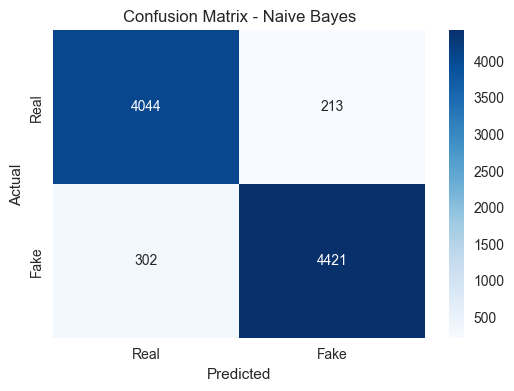

In [11]:
# evaluate
predictions = pipeline_nb.predict(X_test)

# print metrics
print("Baseline Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

# plot confusion matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Second "baseline" Linear SVM (second model)

In [8]:
# compare with SVM
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.7)),
    ('clf', LinearSVC()
    )])

pipeline_svm.fit(X_train, y_train)
svm_acc = pipeline_svm.score(X_test, y_test)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"SVM Accuracy: {svm_acc:.4f}")

# Save the better model
best_model = pipeline_nb if accuracy_score(y_test, predictions) >= svm_acc else pipeline_svm
model_filename = '../models/baseline_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model saved as {model_filename}")

Naive Bayes Accuracy: 0.9427
SVM Accuracy: 0.9950
Best model saved as ../models/baseline_model.pkl
